In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import (
    VGG16, ResNet50, InceptionV3, Xception,
    DenseNet121, EfficientNetB0, MobileNetV2
)

In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/datasets/train"
TEST_DIR = "/content/drive/MyDrive/datasets/test"

In [ ]:
BATCH_SIZE = 32
EPOCHS = 5
IMAGE_SIZE = (224, 224)
LEARNING_RATE = 1e-4
MODEL_NAMES = ["ResNet50"]

In [ ]:
def train_val_generators(TRAINING_DIR, TEST_DIR):
    train_datagen = ImageDataGenerator(
        rescale=1.0/255.0,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(rescale=1.0/255.0)

    train_generator = train_datagen.flow_from_directory(
        TRAINING_DIR,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        target_size=IMAGE_SIZE
    )

    val_generator = val_datagen.flow_from_directory(
        TEST_DIR,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        target_size=IMAGE_SIZE
    )

    return train_generator, val_generator

train_generator, test_generator = train_val_generators(TRAIN_DIR, TEST_DIR)
num_classes = len(train_generator.class_indices)
print("Class labels:", train_generator.class_indices)


Found 5757 images belonging to 21 classes.
Found 1640 images belonging to 21 classes.
Class labels: {'Grape__black_measles': 0, 'Grape__black_rot': 1, 'Grape__healthy': 2, 'Grape__leaf_blight_(isariopsis_leaf_spot)': 3, 'Lemon__diseased': 4, 'Lemon__healthy': 5, 'Pomegranate__diseased': 6, 'Pomegranate__healthy': 7, 'guava_Disease Free': 8, 'guava_Phytopthora': 9, 'guava_Red rust': 10, 'guava_Scab': 11, 'guava_Styler and Root': 12, 'mango_Anthracnose': 13, 'mango_Bacterial Canker': 14, 'mango_Cutting Weevil': 15, 'mango_Die Back': 16, 'mango_Gall Midge': 17, 'mango_Healthy': 18, 'mango_Powdery Mildew': 19, 'mango_Sooty Mould': 20}


In [ ]:
def get_base_model(model_name, input_shape):
    model_map = {
        "VGG16": VGG16,
        "ResNet50": ResNet50,
        "InceptionV3": InceptionV3,
        "Xception": Xception,
        "DenseNet121": DenseNet121,
        "EfficientNetB0": EfficientNetB0,
        "MobileNetV2": MobileNetV2
    }

    base_model_class = model_map.get(model_name)

    if base_model_class is None:
        print(f"Unsupported model name: {model_name}")

    base_model = base_model_class(weights="imagenet", include_top=False, input_tensor=Input(shape=input_shape))
    return base_model

In [ ]:
results = {}

for model_name in MODEL_NAMES:
    print(f"\n==============================")
    print(f" Training {model_name} ")
    print(f"==============================\n")

    base_model = get_base_model(model_name, (224, 224, 3))

    # Freeze base layers
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='categorical_crossentropy', metrics=['accuracy'])

    checkpoint = ModelCheckpoint(f'{model_name}_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
    early_stop = EarlyStopping(monitor='val_loss', patience=3, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)

    history = model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=EPOCHS,
        steps_per_epoch=len(train_generator),
        validation_steps=len(test_generator),
        callbacks=[checkpoint, early_stop, reduce_lr],
        verbose=1
    )

    # Evaluate
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    results[model_name] = {
        "test_acc": test_acc,
        "test_loss": test_loss,
        "history": history.history
    }


    print(f"✅ {model_name} - Test Accuracy: {test_acc:.3f}")


 Training ResNet50 

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 2105s 12s/step - accuracy: 0.1054 - loss: 3.8557 - val_accuracy: 0.2006 - val_loss: 2.6056 - learning_rate: 1.0000e-04
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.2741 - loss: 2.7812 - val_accuracy: 0.3848 - val_loss: 2.1063 - learning_rate: 1.0000e-04
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.3334 - loss: 2.3991 - val_accuracy: 0.5024 - val_loss: 1.6805 - learning_rate: 1.0000e-04
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.3748 - loss: 2.2239 - val_accuracy: 0.5299 - val_loss: 1.5206 - learning_rate: 1.0000e-04
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 179s 992ms/step - accuracy: 0.3895 - loss: 2.0998 - val_accuracy: 0.5549 - val_loss: 1.4561 - learning_rate: 1.0000e-04
✅ ResNet50 - Test Accuracy: 0.555


In [ ]:
print("\nFinal Summary:")
for name, stats in results.items():
    print(f"{name}: Accuracy = {stats['test_acc']:.3f}, Loss = {stats['test_loss']:.3f}")


Final Summary:
ResNet50: Accuracy = 0.555, Loss = 1.456


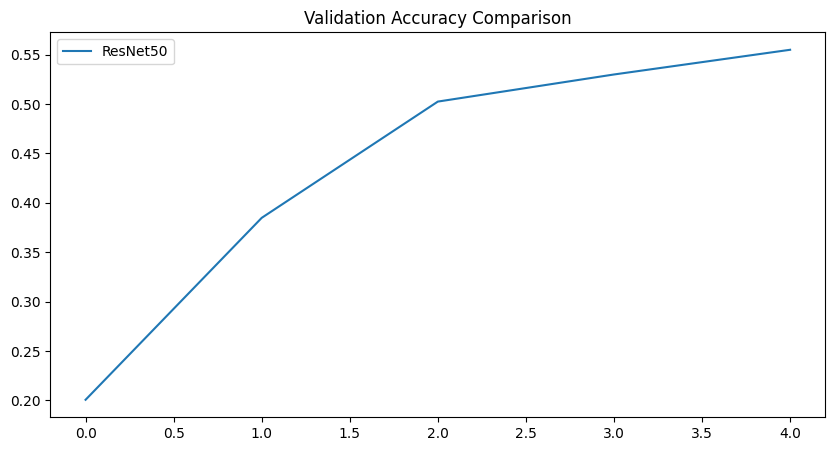

In [ ]:
plt.figure(figsize=(10, 5))
for name, stats in results.items():
    plt.plot(stats['history']['val_accuracy'], label=f"{name}")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()